# Lab 4 instructions

In Lab 3 you explored Discrete event simulation (DES) which simulated sequential events occurring over time.In this lab you will delve deeper into the network and simulate an overloaded switch port and analyse its performance under various conditions. 

## 1. Switch Port - Dropped packets

An overloaded switch port refers to a network switch port that is handling more traffic or data than it can effectively manage. This situation can occur when there are too many devices connected to the port, or when the devices connected are generating more traffic than the port's capacity can handle. When a switch port becomes overloaded, it can lead to network congestion, slow performance, and potential disruptions in connectivity for the devices connected to that port. To resolve this issue, network administrators may need to redistribute devices across multiple ports, upgrade the switch to one with higher capacity, or implement traffic management techniques to alleviate the congestion.

In this exercise we will simulate a network scenario using Classes defined in SimComponents.py, where packets are generated at a constant rate by a PacketGenerator connected to a SwitchPort, and then received by a PacketSink. The class SwitchPort(object):
models a switch output port with a given rate and buffer size limit in bytes. Setting the ".out" member variable to the entity enables receiving of the packet.

Packets will be generated with a interarrival time as defined in

def constArrival(): 

The packets sizes are defined in  

def constSize():

Enter the packet arrival rate: 10  
Enter the packet size (in bytes): 10  
Enter the rate for the switch port (bits/sec): 8 (means 1 byte/sec)  
Enter the qlimit for the switch port (bytes): 11  


### Exercise 1.1
Examine the code provided below and open the Simcomponents.py file and study the SwitchPort Class.   

1. Open the SwitchPort class of the SimComponents.py and examine the key parameters with units. 
          
       -Enter the packet Inter-arrival time input (1/arrival rate): 10
       -Enter the packet size (in bytes): 10
       -Enter the rate for the switch port (bits/sec):  choose 5, 8, 9
       -Enter the qlimit for the switch port (bytes): 11                  

For the above input parameters, is the queue stable? Is utilization (< 1)? For a smaller switch port rate that results in dropped packets, can you recommend a buffer size that results in 0 dropped packets (Hint: Check the problem solved in Workshop 6)? Obviously, a larger buffer will solve the problem, but how can we determine the minimum buffer size that results in 0 dropped/lost packets?

For switch port rate 5 b/s: utilisation is 1.6, and the queue is not stable.   
For switch port rate 8 b/s: utilisation is 1, and the queue is stable.   
For switch port rate 9 b/s: utilisation is 0.89, and the queue is stable.   

For a simulation time of 1000, a buffer size of 371 bytes leads to 0 packets dropped for the switch port rate 5 b/s. This is silly however, as the queue size will grow to infinity given infinite time as the arrival rate is higher than the servcie rate. We are just stopping tyhe simulation early.

  
 #### Example inputs (from your run)
- **Inter-arrival time input**: 10
  - Arrivals at times: 10, 20, 30, …, 90
  - Effective arrival **rate**: $\lambda = 1/10 = 0.1$ packets/time unit
- **Packet size**: 10 bytes → $80$ bits
- **Link rate**: 9 bits/sec
- **Buffer `qlimit`**: 11 bytes (with Packet size =10bytes choosing qlimit = 11 hold 1 packet in buffer)
- **Simulation horizon**: `env.run(until=100)`

#### Derived Service Time
$$
T_s = \frac{\text{packet bits}}{\text{link rate}} = \frac{80}{9} \approx 8.8889 \text{ time units}
$$

#### Utilization (Traffic Intensity)
$$
\rho = \lambda \cdot T_s = 0.1 \times 8.8889 \approx 0.8889 < 1
$$

Since $\rho < 1$, the server can keep up on average; the queue does not grow without bound.

  

- What is the minimum switch port output rate that results in any dropped packets OR Traffic Intensity >1?  

This happens if the output rate is lower than the arrival rate. The arrival rate is 0.1*80 = 8 bits/s. So the value at which we see dropped packets is when output rate < 8, or = 7 or less.
- How do network designers determine an appropriate switch port rate to minimize wait times while maintaining network efficiency and reliability? Discuss the factors that influence switch port rate decisions and the trade-offs involved in selecting an optimal rate for a given network environment?  

They need to compare the choices of switch port rate to the arrival rates of packets and make sure that the arrival rate os lower. They need to consider targets for delay, packet loss, and utilisation. They need to select a service rate high enough to minimise queueing delays and packet loss, but not so high that that resources are wasted. If you go too high, it increases cost and energy usage.

        
5. Run the Switch port code above and provide inputs for Switch port rate and qlimit for the below three scenarios
 
- Overloaded switch port scenario when all packets sent are Dropped  $\rho > 1$.

Silly question, you cant get ALL of them dropped as one will always get through as the queue is empty at the start

- Overloaded switch port scenario results in some Dropped packets $\rho = 1$

Switch port rate = 5 and qlimit = 11 gave some dropped

- Underloaded switch port scenario results in No dropped packets. $\rho < 1$

Switch port rate = 9 and qlimit = 11 gave none dropped

*From the results can you conclude on the relationship between Packet inter arrival time and Packet service time $T_s$*

$\rho = \frac{\lambda}{\mu} = \frac{T_s}{\text{inter arrival time}}$
    
For the below 
     
         - Enter the inter-arrival time: 10
         - Enter the packet size (in bytes): 10
      
### Exercise 1.2    Blocking probability
6. In the second scenario, calculate the blocking probability. Discuss the transmission parameters that have a significant 
   impact on the probability of blocking or dropping a packet. How do factors such as switch port rate, queue limit, and packet 
   arrival rate contribute to the blocking probability, and what strategies can be employed to mitigate high blocking 
   probabilities in network designs?

    
In the provided code, ps.waits is used to access the attribute waits of the PacketSink object ps. The waits attribute keeps track of the waiting times of packets at the PacketSink. Each time a packet arrives at the PacketSink, it calculates the time it waited in the queue before being processed. These waiting times are then accumulated in the waits attribute.

7. Examine the PacketSink Class in SimComponents and explain how the wait times of the switch port are calculated. Comment on the relationship between switch port rate and wait times. See above example.

8. Choose appropriate value for switch port rate so that it meets a delay QoS spec of less than 5 seconds with no dropped packets
            
                     
       -Enter the packet inter-arrival time: 10
       -Enter the packet size (in bytes): 10
       -Enter the qlimit for the switch port (bytes): 11
       -Enter the rate for the switch port (bits/sec):  Choose minimal rate to satisfy the Delay less than 5 seconds 

Conclusion/Learning: Please comment on the switch port rate required to meet a certain QoS and what it depends on.





In [ ]:
import simpy
from SimComponents import PacketGenerator, PacketSink, SwitchPort
import numpy as np

def constArrival():
    return 10 # float(input("Enter the packet inter-arrival-time: "))  

def constSize():
    return 10 # float(input("Enter the packet size (in bytes): "))  


inter_arrival = constArrival()
packet_size = constSize()

rate = [5, 8, 9] # float(input("Enter the rate for the switch port (bits/sec): "))
qlimit = 11 # int(input("Enter the qlimit for the switch port (bytes): ")) # Note qlimit is an integer for buffer size limit in 
# bytes or packets for the queue (including items in service).

for r in rate:
    print("\nSimulating with switch port rate: {} bits/sec".format(r))
    env = simpy.Environment()  # Create the SimPy environment
    ps = PacketSink(env, debug=False)  # Disable debugging for PacketSink
    pg = PacketGenerator(env, "My_Name", lambda: inter_arrival, lambda: packet_size)

    switch_port = SwitchPort(env, r, qlimit,debug=False)

    # Wire packet generators and sinks together
    pg.out = switch_port
    switch_port.out = ps

    env.run(until=1000)

    print("Waits: {}".format(ps.waits))
    print("Received: {}, Dropped: {}, Sent: {}".format(ps.packets_rec, switch_port.packets_drop, pg.packets_sent))






Simulating with switch port rate: 2 bits/sec
Waits: [40.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0]
Received: 24, Dropped: 73, Sent: 99

Simulating with switch port rate: 5 bits/sec
Waits: [16.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0, 22.0, 28.0, 24.0, 30.0, 26.0]
Received: 61, Dropped: 36, Sent: 99

Simulating with switch port rate: 8 bits/sec
Waits: [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0

### Exercise 1.3
1. How do exponential arrivals and/or packet sizes change queue behaviour compared to deterministic ones?
2. Similar to the deterministic queue in the above exercise, is it possible to predict the buffer size?
3. If not, why not? Can you recommend a workaround? We will derive the steady-state probabilities of single-server finite-buffer queues in future workshops to make a theoretical prediction of the blocking probability.




In [ ]:
import simpy
import random
from SimComponents import PacketGenerator, PacketSink, SwitchPort

# Exponential arrival times: mean inter-arrival time = 1 / λ
def expArrival(InterTime):
    
    return random.expovariate(1/InterTime)

# Exponential packet size: mean size = avg_size
def expSize(avg_size):
    return random.expovariate( avg_size)

env = simpy.Environment()  # Create the SimPy environment

# Prompt the user for exponential distribution parameters
InterTime = float(input("Enter the packet inter arrival time ): "))
avg_size = float(input("Enter the average packet size (bytes): "))

ps = PacketSink(env, debug=False)  # Disable debugging (avoids printing intermediate outputs) for PacketSink

pg = PacketGenerator(env,"My_Name", lambda: expArrival(InterTime), lambda: expSize(avg_size))

rate = float(input("Enter the rate for the switch port (bits/sec): "))
qlimit = int(input("Enter the qlimit for the switch port (bytes): "))
switch_port = SwitchPort(env, rate, qlimit,debug=False) # Disable debugging by choosing False (avoids printing intermediate outputs) for PacketSink

# Wire packet generators and sinks together
pg.out = switch_port
switch_port.out = ps

env.run(until=100)

print("Waits: {}".format(ps.waits))
print("Received: {}, Dropped: {}, Sent: {}".format(ps.packets_rec, switch_port.packets_drop, pg.packets_sent))

# Calculate average wait time if packets were received
if ps.waits:
    total_wait_time = sum(ps.waits)
    average_wait_time = total_wait_time / len(ps.waits)
    print("Average wait time: {:.2f} time units".format(average_wait_time))
else:
    print("No packets received, cannot compute average wait time.")


## 2. Relation between switch port processing rate and average waiting times of the packet

In this exercise we will simulate a network scenario using SimComponents, where packets are generated at a constant rate by a PacketGenerator, transmitted through a SwitchPort, and then received by a PacketSink. The average wait time experienced by packets in the switch port's queue is then plotted against different port rates. From this we can calculate the minimum port rate necessary given a certain delay requirement. We will fix the packet generation parameters **constArrival =10**,  packet size **constSize=10** and switch port buffer size **qlimit to 11** (a minimum of 1 packet in the buffer) and investigate the port rate requirement to meet a certain delay specification.

### Exercise 2
For the fixed parameters for packet generation and qlimit, and below parameters for the swtich port rates, plot 

    - Enter the minimum switch port rate: 1
    - Enter the maximum switch port rate: 100
    -Enter the step size for switch port rates: 1

1. Plot wait times versus port rates
2. Plot dropped packets versus port rates
3. At what port rate does the decrease in average wait time become moderate? What is the relationship between this port rate and the chosen packet size and inter-arrival time? 





Enter the minimum switch port rate:  1
Enter the maximum switch port rate:  100
Enter the step size for switch port rates:  1


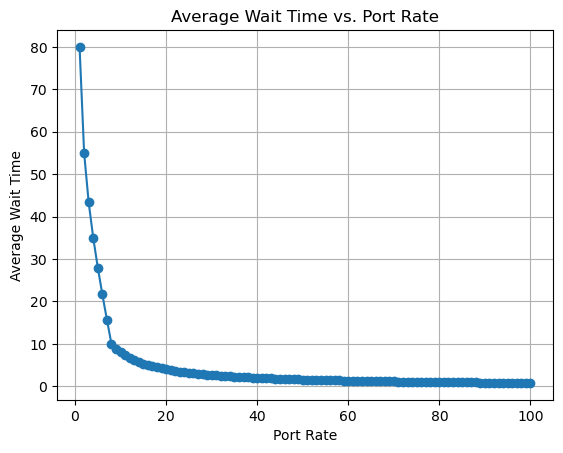

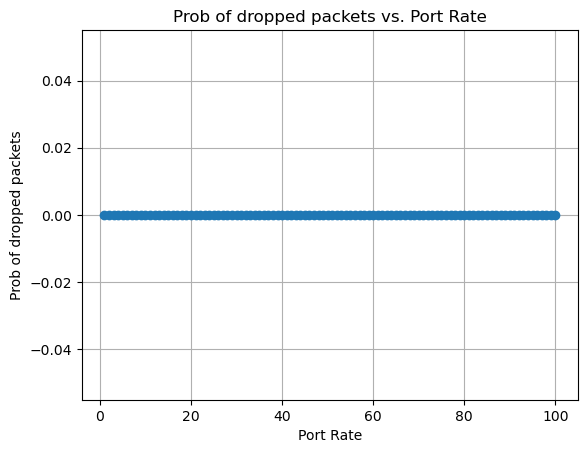

In [14]:
import simpy
from SimComponents import PacketGenerator, PacketSink, SwitchPort
import matplotlib.pyplot as plt

def constArrival():
    return 10 # time interval

def constSize():
    return 10  # bytes

# Function to run simulation and return average wait time and number of dropped packets
def run_simulation(port_rate):
    env = simpy.Environment()  # Create the SimPy environment
    ps = PacketSink(env, debug=False) # debug: every packet arrival is printed
    pg = PacketGenerator(env, "Name", constArrival, constSize)
    switch_port = SwitchPort(env, rate=port_rate, qlimit=1000,debug=False)
    # Wire packet generators and sinks together
    pg.out = switch_port
    switch_port.out = ps
    
    env.run(until=100)
    # Calculate average wait time
    total_wait_time = sum(ps.waits)
    average_wait_time = total_wait_time / len(ps.waits)
    return average_wait_time, switch_port.packets_drop, pg.packets_sent  # Return both average wait time and number of dropped packets

# User inputs for the range of switch port rates to simulate
min_rate = int(input("Enter the minimum switch port rate: "))
max_rate = int(input("Enter the maximum switch port rate: "))
step = int(input("Enter the step size for switch port rates: "))

# List of port rates to simulate
port_rates = list(range(min_rate, max_rate + 1, step))

# Run simulations and collect average wait times and number of dropped packets
average_wait_times = []
drop_prob = []

for rate in port_rates:
    avg_wait_time, dropped_pkts, sent_pkts = run_simulation(rate)
    average_wait_times.append(avg_wait_time)
    drop_prob.append(float(dropped_pkts / sent_pkts))
    

# Run simulations and collect average wait times


# Plot wait times (Y axis) versus port rates (X axis)



# Plot port_rates Vs drop_prob




Examine the code in Section 2 and note the input rate to the switch port and the range (min and max) processing rates of the switch port. 



3. Label axis for the plots and provide appropriate titles. 

4. From the first plot, by visual inspection, what is the minimum port rate needed to satisfy a delay requirement of 20 time units and 50 timeunits?you may want to use the below code


In [10]:
# Find the smallest port rate resulting in near-zero waiting time
smallest_port_rate = None
delay_spec = float(input("Enter the delay spec from the previous step for the switch port: "))
for rate, wait_time in zip(port_rates, average_wait_times):
    if wait_time < delay_spec:  # Adjust the threshold as needed
        smallest_port_rate = rate
        break

if smallest_port_rate is not None:
    print("The smallest port rate resulting in waiting time specified is:", smallest_port_rate)
else:
    print("No port rate that meets the waiting time spec (delay spec).")

Enter the delay spec from the previous step for the switch port:  20


The smallest port rate resulting in waiting time specified is: 6


5. At what port rate does the drop probability ≈ 0*, and what does that imply about **traffic intensity** $\rho$?
6. Where is the knee in the average wait curve, and why does the slope change there?
7. Increase the qlimit to a large value like a 1000, what is the impact on average wait times and dropping probability?

9. If arrivals switch from deterministic to **exponential** (same mean), how do both curves change? Justify using variability/SCV.
10. Comment on the smallest port rate that meets  a certain delay specification. From this can you summarize the effect of  packet size, inter-arrival times on the waiting time? Also, explain how this relationship is useful in optimizing a network. 

## 3. Switch port with exponential packet inter-arrival times
Now let's see how to simulate an switching port with exponential packet inter-arrival times, and exponentially distributed packet sizes. With a FIFO queueing discipline and no limit on queue sizes such a system is equivalent to the well known M/M/1 queueing system which has nie analytical expressions for average queue size and waiting times.

- **Average wait time** is the mean of the packet waiting times recorded by `ps.waits`.
- **Loss rate** is calculated as:

$$
  \text{Loss rate} = \frac{\text{dropped packets}}{\text{received packets} + \text{dropped packets}}
 $$

- **Average system occupancy** is the time-average number of packets in the system, estimated from the port monitor samples(pm).
- Compare the observed average system occupancy with **Little’s Law**:

  $$
 E[N_Q] \approx \lambda_{\text{eff}} E[N_D]
  $$

  where:
  - $E[N_Q]$ is the average number of packets in the system,
  - $\lambda_{\text{eff}}=$ Rec.Packets/Sent packets  is the effective arrival rate,
  - $E[N_D]$ is the average wait time.

### Exercise 3


1. What is the average inter arrival time and service time of packets
2. What is the average packet size
3. Explain the purpose of samp_dist parameter in the code below

Run the code for the below parameters

Enter the arrival rate:  0.1
Enter the packet size:  10
Enter the sampling rate:  8
Enter the port rate:  8
Enter the queue limit:  11
Enter the simulation time:  1000

4. Is the system critically loaded?
5.   $ E[N_Q]  $ is the average occupancy of the system and  $ E[N_D]  $ Average waiting time, verify Littles law. 

In [39]:
import random
import simpy
import numpy as np
import matplotlib.pyplot as plt
from SimComponents import PacketGenerator, PacketSink, SwitchPort, PortMonitor

# Take user inputs for the parameters
arrival_rate = float(input("Enter the arrival rate Packets/sec: "))
packet_size = float(input("Enter the packet size in bytes: "))
sampling_rate = float(input("Enter the sampling rate (samples/sec): "))
port_rate = float(input("Enter the port rate bits/sec: "))
queue_limit = int(input("Enter the queue limit bytes: "))
simulation_time = float(input("Enter the simulation time over 1000sec: "))


# Create the distributions using user inputs
adist = lambda: random.expovariate(arrival_rate)      # inter-arrival time
sdist = lambda: random.expovariate( packet_size) # mean packet size
samp_dist = lambda: random.expovariate(sampling_rate) # monitor sampling interval

env = simpy.Environment()  # Create the SimPy environment

# Create the packet generator and sink
ps = PacketSink(env, debug=False, rec_arrivals=True)
pg = PacketGenerator(env, "PacketGen", adist, sdist)
switch_port = SwitchPort(env, port_rate, qlimit=queue_limit, debug=False)

# Use a PortMonitor to track queue sizes over time
pm = PortMonitor(env, switch_port, samp_dist)

# Wire packet generator, switch port, and sink together
pg.out = switch_port
switch_port.out = ps

# Run the simulation
env.run(until=simulation_time)

print("Received: {}, Dropped: {}, Sent: {}".format(ps.packets_rec, switch_port.packets_drop, pg.packets_sent))

# Print statistics
if len(ps.waits) > 0:
    print("Average wait time: {:.3f}".format(float(np.mean(ps.waits))))
else:
    print("Average wait time: 0.000")

total_packets = ps.packets_rec + switch_port.packets_drop
if total_packets > 0:
    print("Loss rate: {:.3f}".format(float(switch_port.packets_drop / total_packets)))
else:
    print("Loss rate: 0.000")

if len(pm.sizes) > 0:
    print("Average system occupancy: {:.3f}".format(float(np.mean(pm.sizes))))
else:
    print("Average system occupancy: 0.000")

print("Waits: {}".format(ps.waits))

Enter the arrival rate:  0.1
Enter the packet size:  10
Enter the sampling rate:  8
Enter the port rate:  8
Enter the queue limit:  11
Enter the simulation time:  1000


Received: 115, Dropped: 0, Sent: 115
Average wait time: 0.086
Loss rate: 0.000
Average system occupancy: 0.010
Waits: [0.0908184615218488, 0.027194871360524786, 0.13900806598640258, 0.026260611921486543, 0.039424056384206096, 0.12401908357003322, 0.048129876922004655, 0.008139712630040208, 0.07086433180840856, 0.15775789128478834, 0.11305433255267872, 0.040386174248197904, 0.0016113106789816811, 0.10763915534269586, 0.1884250383107826, 0.025470765919806126, 0.23713034729243532, 0.04733464387120989, 0.21143554660343966, 0.025902787145241746, 0.15386235104250545, 0.02042974067651926, 0.08620050682461056, 0.003033014815258639, 0.02027301910069923, 0.02782568247994277, 0.15946686644394958, 0.09392190156438573, 0.1361998854479225, 0.0884962314773361, 0.03822601161039074, 0.0035740479434025474, 0.0582267646972241, 0.10525268679106148, 0.01228975663974552, 0.07584909102581605, 0.07122182309058189, 0.016208868050000547, 0.14202317135345766, 0.38718135913234164, 0.09856842134206545, 0.144491858